# Где дешевле жить? Предсказание цен в Airbnb - учимся генерировать признаки и интерпретировать результаты модели

## Тезисы

1. В работе проведен первичный анализ, обработка (удаление признаков) и визуализация данных.

2. На первом шаге подготовки данных применяем OrdinalEncoder и StandardScaler. 

3. Обучаем базовую модель линейной регрессии на полном наборе данных. Получаем низкий R2, делаем вывод о непригодности модели.

4. Проводим дополнительную обработку данных и используем модели с регуляризацией: 

- добавляем признак расстояния до центра Манхэттена;
- обрабатываем "выбросы" на примере модели LassoCV.

5. Получим сводную статистику для следующих инструментов:

- кодирование дискретных признаков: OrdinalEncoder, CountEncoder, OneHotEncoder;
- масштабирование непрерывных признаков: StandardScaler, MinMaxScaler, Normalizer;
- модели регрессии: LassoCV, RidgeCV, ElasticNetCV

По результатам работы можно сделать следующие выводы:
- без модификации признаков и обработки "выбросов" модель дает низкие показатели качества;
- самое существенное влияние на результаты имеет обработка "выбросов";
- модели в данном случае имют сходные показатели качества;
- StandardScaler и MinMaxScaler работают существенно лучше, чем Normalizer при любых кодировщиках;
- OneHotEncoder дает лучшие показатели, чем OrdinalEncoder и тем более чем CountEncoder. Однако при использовании Normalizer он дает самые низкие показатели;
- итого имеем в целом лучшие показатели при использовании StandardScaler и OneHotEncoder в моделях LassoCV и RidgeCV, худшие - для Normalizer и OneHotEncoder в модели ElasticNetCV;
- вообще, лучшее значение R2 приближается к 0.44 при умеренном удалении "выбросов". Существенно улучшить качество модели не удается. Возможно, требуется иной подход к обработке данных и моделированию.

## 1. Импортируем библиотеки, загружаем датасет и анализируем данные

In [360]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [361]:
df=pd.read_csv('https://github.com/bvstnv-lab/ML-Basic/tree/main/homework_10/AB_NYC_2019.csv')

Получаем первое представление о данных

In [362]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [363]:
df.head(3)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365


In [364]:
df.isna().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

Делаем предположение о столбцах, не имеющих отношения к дальнейшему анализу

In [365]:
df.drop(columns=['id','name','host_id','host_name','last_review'], inplace=True)

Отсутствующие значения остались только в колонке "просмотры за месяц". Можем заменить их нулями

In [366]:
df['reviews_per_month'].fillna(0.0, inplace=True)

In [367]:
df.isna().sum()

neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

Посмотрим статистику по числовым признакам:

In [368]:
df.describe()

,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000
mean,40.728949,-73.952170,152.720687,7.029962,23.274466,1.090910,7.143982,112.781327
std,0.054530,0.046157,240.154170,20.510550,44.550582,1.597283,32.952519,131.622289
min,40.499790,-74.244420,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,40.690100,-73.983070,69.000000,1.000000,1.000000,0.040000,1.000000,0.000000
50%,40.723070,-73.955680,106.000000,3.000000,5.000000,0.370000,1.000000,45.000000
75%,40.763115,-73.936275,175.000000,5.000000,24.000000,1.580000,2.000000,227.000000
max,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


Построим некоторые визуализации. Для начала зададим глобальные настройки графики

In [369]:
sns.set_theme(style="whitegrid")

plt.rcParams.update({
    'font.size': 14,             
    'figure.figsize': (10, 6),   
    'axes.labelsize': 14,        
    'xtick.labelsize': 12,      
    'ytick.labelsize': 12,       
    'legend.fontsize': 12        
})

1. Распределения признаков

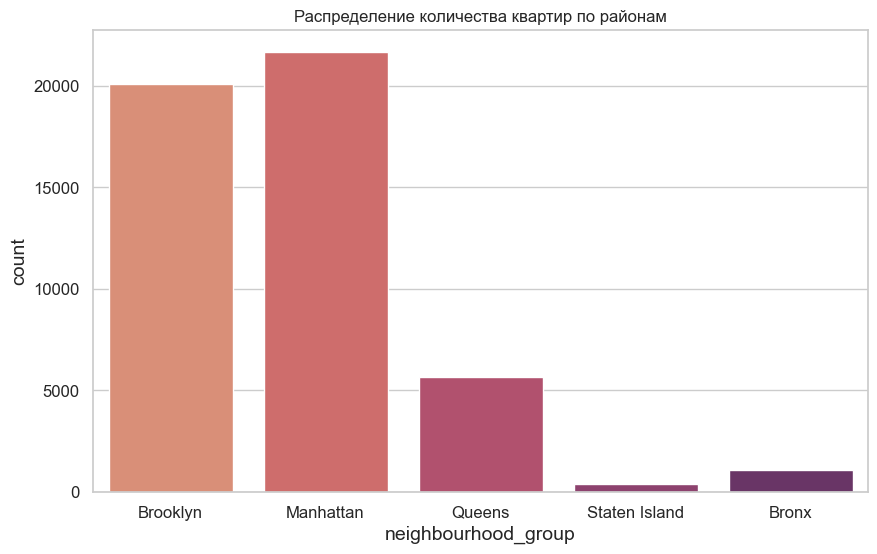

In [370]:
sns.countplot(
    data=df,
    x='neighbourhood_group',
    palette="flare"
)
plt.title('Распределение количества квартир по районам');
plt.show()

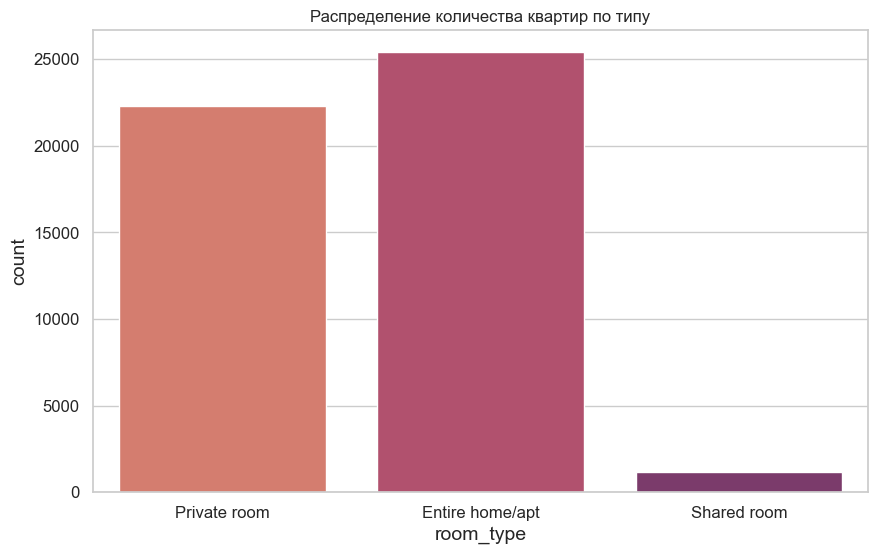

In [371]:
sns.countplot(
    data=df,
    x='room_type',
    palette="flare"
)
plt.title('Распределение количества квартир по типу');
plt.show()

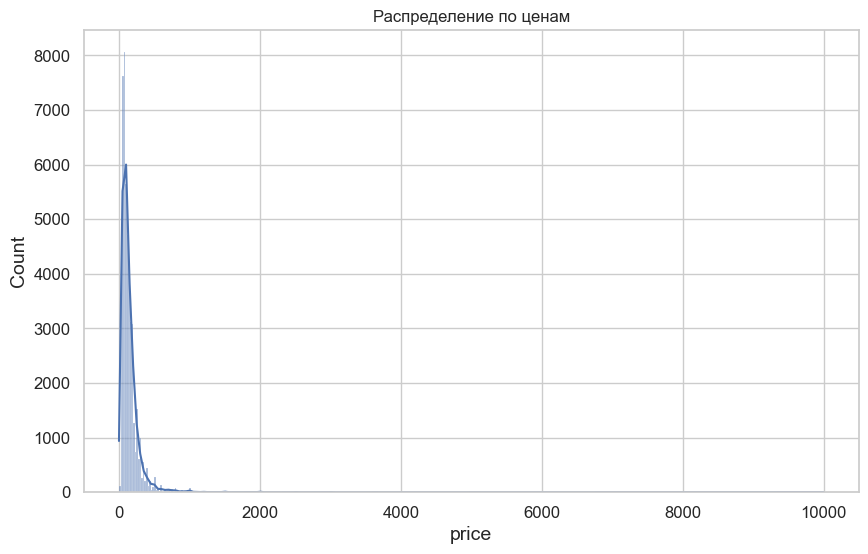

In [372]:
sns.histplot(
    data=df,
    x='price',
    kde=True
)
plt.title('Распределение по ценам');
plt.show()

Видим, что распределение сильно смещено и большинство цен не превышает 1000. Для наглядности выясним процент превышений и разделим датасеты для построения графиков

In [373]:
len(df.index[df['price']>1000])

239

In [374]:
100*len(df.index[df['price']>1000])/len(df.index)

0.48880253604663054

In [375]:
df_reg=df.drop(df.index[df['price']>1000], axis=0)

In [376]:
df_add=df.drop(df.index[df['price']<1000], axis=0)

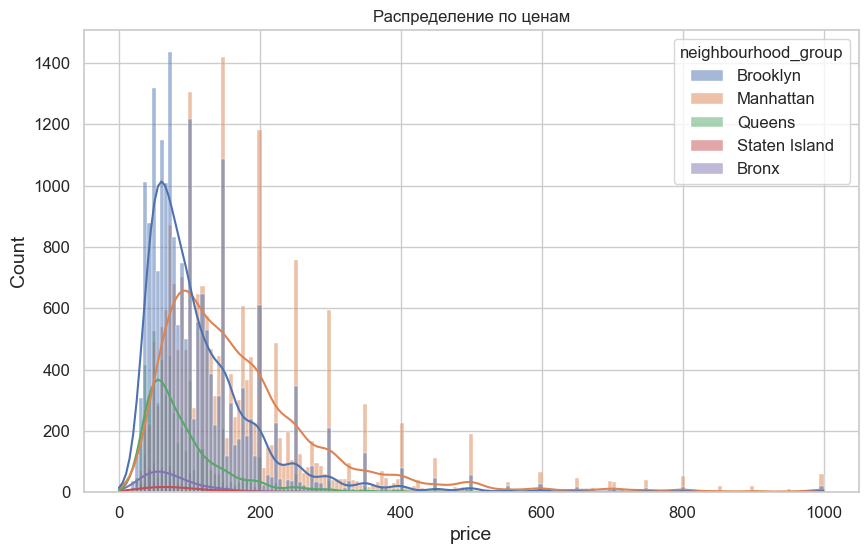

In [377]:
sns.histplot(
    data=df_reg,
    x='price',
    hue='neighbourhood_group',
    kde=True
)
plt.title('Распределение по ценам')
plt.show()

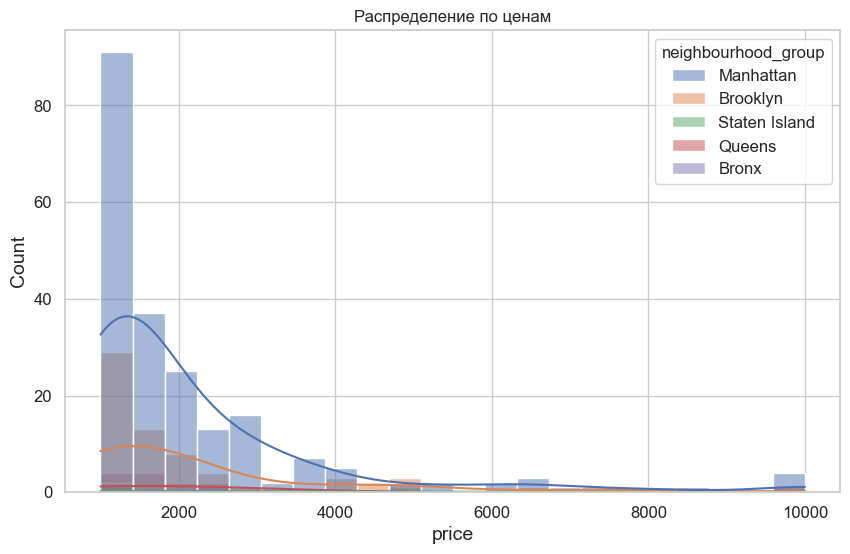

In [378]:
sns.histplot(
    data=df_add,
    x='price',
    hue='neighbourhood_group',
    kde=True
)
plt.title('Распределение по ценам')
plt.show()

Графики показывают, как в Бруклине плотно сконцентрированы относительно недорогие кваритры, в Квинсе и Бронксе ситуация аналогичная, только предложений меньше. На Манхэттене представлено чуть больше дорогих вариантов и распределение несколько сдвинуто вправо. Проверим отдельно Стэйтен Айленд, так как он теряется в общем масштабе.
    

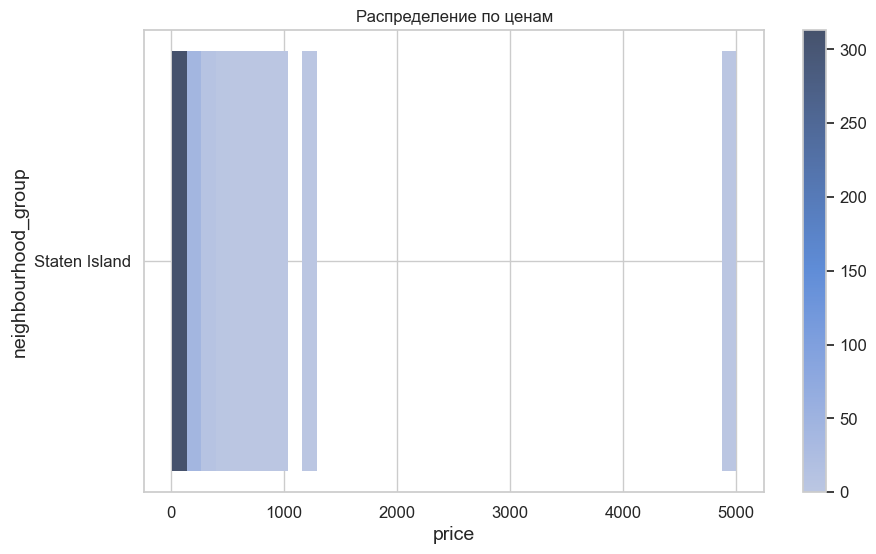

In [379]:
sns.histplot(
    data=df.loc[df['neighbourhood_group']=='Staten Island'],
    x='price',
    y='neighbourhood_group',
    hue='neighbourhood_group',
    legend=False,
    cbar=True   
)
plt.title('Распределение по ценам')
plt.show()

В целом картина похожая, только объявлений сильно меньше, чем в остальных районах.

Интересно выглядит карта объектов:

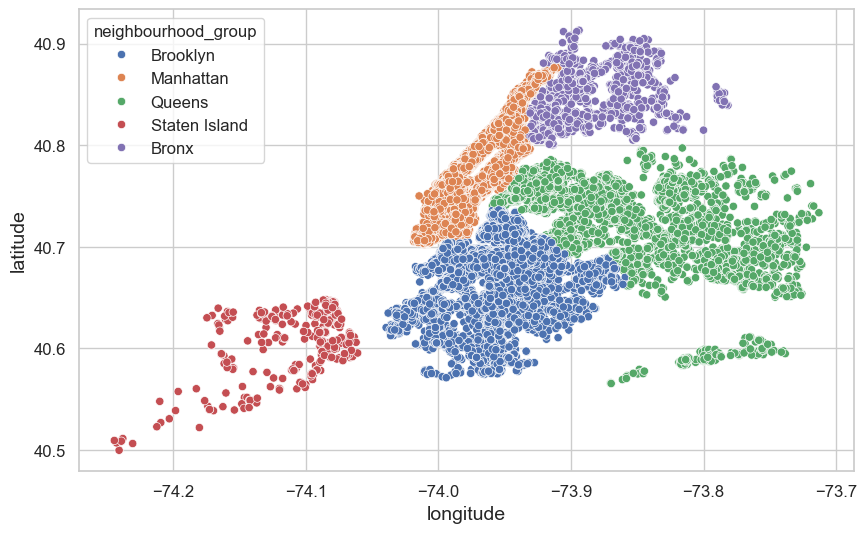

In [380]:
sns.scatterplot(df, x='longitude', y='latitude', hue='neighbourhood_group')
plt.show()

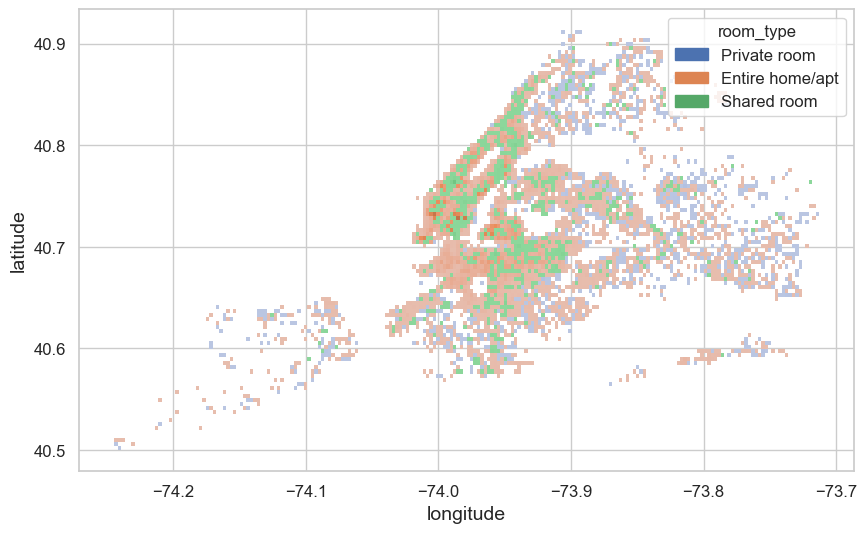

In [381]:
sns.histplot(df, x='longitude', y='latitude', hue='room_type')
plt.show()

2. Построим теперь матрицу корреляций

In [382]:
cols=['price','latitude','longitude','minimum_nights','number_of_reviews','reviews_per_month','calculated_host_listings_count','availability_365']
corr = df[cols].corr()

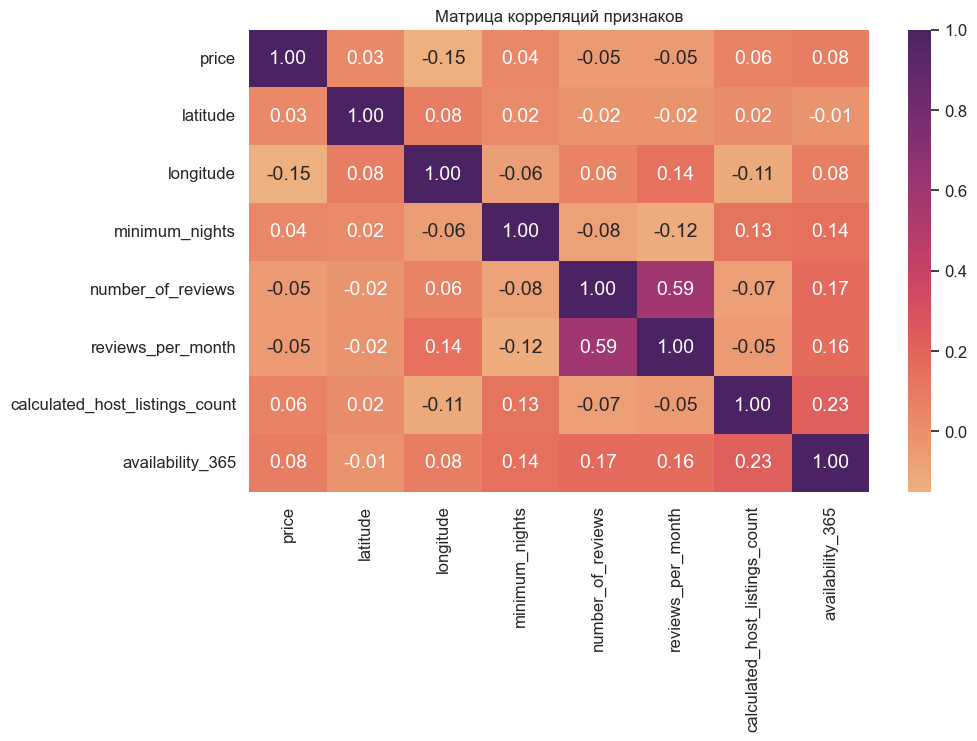

In [383]:
sns.heatmap(
    corr,
    annot=True,
    cmap='flare',
    fmt='.2f'
)
plt.title('Матрица корреляций признаков')
plt.show()

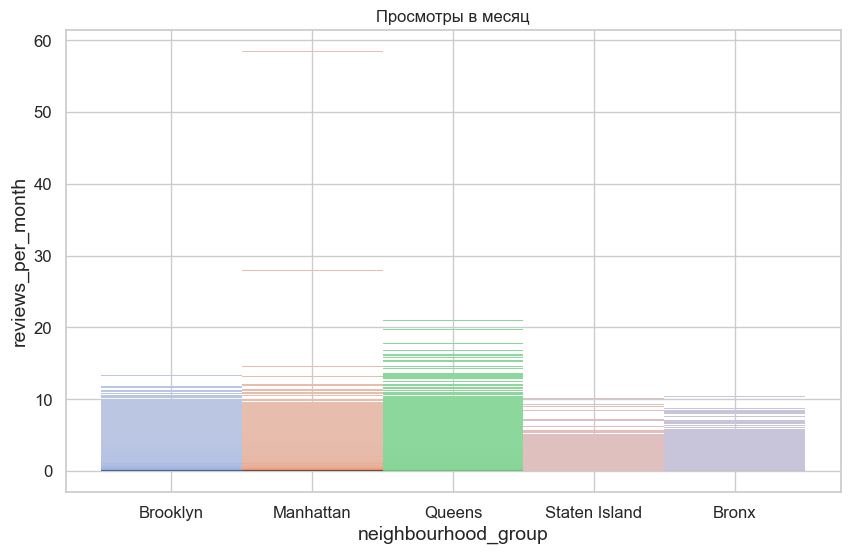

In [384]:
sns.histplot(
    data=df,
    x='neighbourhood_group',
    y='reviews_per_month',
    hue='neighbourhood_group',
    legend=False
)
plt.title('Просмотры в месяц')
plt.show()


Судя по всему, Квинс пользуется популярностью. Хотя, есть и определенные ценители Манхэттена.

3. Построим попарные диаграммы рассеяния. Выглядит красиво.

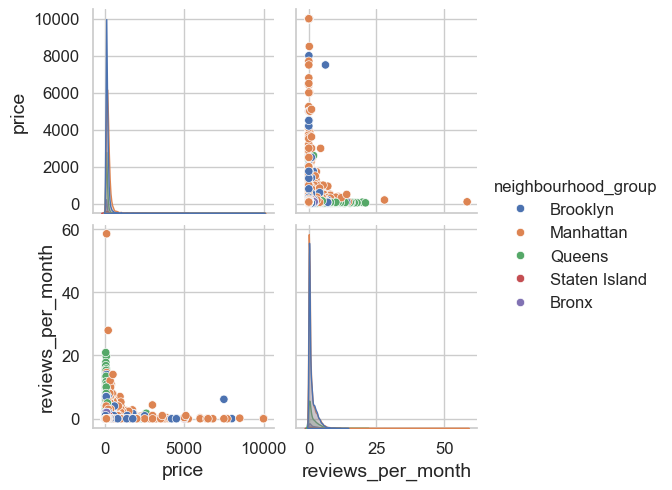

In [385]:
sns.pairplot(
    df.loc[:,['price','neighbourhood_group','reviews_per_month']],
    hue='neighbourhood_group'
)
plt.show()

## 2. Проведем обработку признаков

In [386]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, Normalizer, OneHotEncoder, OrdinalEncoder
from category_encoders import CountEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

Подготовим сводную таблицу результатов

In [387]:
score_data=pd.DataFrame(columns=['Model', 'Scaler', 'Score', 'OrdinalEncoder', 'CountEncoder', 'OneHotEncoder'])
score_data['Model']=['LassoCV']*9+['RidgeCV']*9+['ElasticNetCV']*9
score_data['Scaler']=(['StandardScaler']*3+['MinMaxScaler']*3+['Normalizer']*3)*3
score_data['Score']=['MAE','RMSE','R2']*9
score_data=score_data.set_index(['Model','Scaler','Score'])

Проверим количество категорий признаков:

In [388]:
df[['neighbourhood_group','neighbourhood','room_type']].nunique()

neighbourhood_group      5
neighbourhood          221
room_type                3
dtype: int64

Сделаем предположение, что признаки количества просмотров не влияют на цену

In [389]:
df_prep=df.drop(['number_of_reviews','reviews_per_month'], axis=1)

Зададим функцию кодирования категориальных признаков:

In [390]:
def encode_func(data, cols, enc):
    data_enc = data.copy()
    data_enc[cols]= enc.fit_transform(data_enc[cols])
    return data_enc

Используем сначала Ordinal Encoding и StandardScaler

In [391]:
cols = ['neighbourhood_group','neighbourhood','room_type']
enc = OrdinalEncoder()
scaler = StandardScaler()

In [392]:
df_encoded = encode_func(df_prep,cols,enc)

Разделим выборку:

In [393]:
X_train, X_test, y_train, y_test = train_test_split(df_encoded.drop('price', axis=1), df_encoded['price'], test_size=0.3, random_state=42)
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 3 Выполним расчет показателей базовой модели

In [394]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Test MAE = %.4f" % mean_absolute_error(y_test, y_pred))
print("Test RMSE = %.4f" % root_mean_squared_error(y_test, y_pred))
print("Test R2 = %.4f" % r2_score(y_test, y_pred))


Test MAE = 72.5390
Test RMSE = 188.8808
Test R2 = 0.1167


Получили далеко не лучшие показатели. Низкий R2 показывает, что модель плохо объясняет данные. 
Попробуем провести дополнительную обработку признаков. Добавим новую переменную расстояния до центра Манхэттена как показатель удаленности объекта.
За точку отсчета примем координаты Центрального парка: 40.782507, -73.965502.
Вспомним также график распределения цен. Очень длинный и легкий "хвост" говорит о "выбросах " в данных. Проверим, как сработает модель с регуляризацией.

## 4 Проведем дополнительную обработку данных и моделирование

In [395]:
df_prep['distance']=((df_prep['latitude']-40.782507)**2+(df_prep['longitude']-(-73.965502))**2)**(1/2)
df_prep=df_prep.drop(columns=['latitude','longitude'])
df_prep.head(10)

,neighbourhood_group,neighbourhood,room_type,price,minimum_nights,calculated_host_listings_count,availability_365,distance
0,Brooklyn,Kensington,Private room,149,1,6,365,0.135192
1,Manhattan,Midtown,Entire home/apt,225,1,2,355,0.034179
2,Manhattan,Harlem,Private room,150,3,1,365,0.035496
3,Brooklyn,Clinton Hill,Entire home/apt,89,1,1,194,0.097536
4,Manhattan,East Harlem,Entire home/apt,80,10,1,0,0.026812
5,Manhattan,Murray Hill,Entire home/apt,200,3,1,129,0.036109
6,Brooklyn,Bedford-Stuyvesant,Private room,60,45,1,0,0.096102
7,Manhattan,Hell's Kitchen,Private room,79,2,1,220,0.026226
8,Manhattan,Upper West Side,Private room,79,2,1,0,0.019350
9,Manhattan,Chinatown,Entire home/apt,150,1,4,188,0.073408


In [396]:
from sklearn.linear_model import LassoCV, RidgeCV, ElasticNetCV

model=LassoCV(alphas=10)
df_encoded = encode_func(df_prep.drop(df_prep.index[df_prep['price']>600], axis=0),cols,enc)

X_train, X_test, y_train, y_test = train_test_split(df_encoded.drop(['price'], axis=1), df_encoded['price'], test_size=0.3, random_state=42)
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Test MAE = %.4f" % mean_absolute_error(y_test, y_pred))
print("Test RMSE = %.4f" % root_mean_squared_error(y_test, y_pred))
print("Test R2 = %.4f" % r2_score(y_test, y_pred))


Test MAE = 50.8669
Test RMSE = 75.1748
Test R2 = 0.3503


Для обучения модели опытным путем находим верхнюю границу цены, выше которой объекты считаются "выбросами" и не участвуют в расчетах (в строчке формирования df_encoded). 
Так для полного датасета (df_prep['price']>10000) r2_score остается на уровне 0.1. 

При df_prep['price']>200 достигаем максимума r2_score=0.45. Однако это 17% данных и врядли такие потери допустимы.

При df_prep['price']>600 (теряем 1,5% данных) достигаем r2_score=0.35.

При df_prep['price']>1000 (теряем 0,5% данных) достигаем r2_score=0.26.

От выбранной модели, кстати, существенно не зависит.

Примем для сравнения верхнюю границу цены 600 и выполним расчет в цикле с заполнением сводной таблицы.

# 5. Итоговая статистика

In [397]:
for m in [LassoCV, RidgeCV, ElasticNetCV]:
    model = m(alphas=10)
    for s in [StandardScaler, MinMaxScaler, Normalizer]:
        scaler = s()
        for e in [OrdinalEncoder, CountEncoder, OneHotEncoder]:
            enc = e()
            if e == OneHotEncoder:
                enc = e(sparse_output=False)
                df_encoded = df_prep.drop(df_prep.index[df_prep['price']>600], axis=0).reset_index()
                df_onehot = pd.DataFrame(enc.fit_transform(df_encoded[cols]))
                df_encoded = df_encoded.drop(cols, axis=1).join(df_onehot)
                df_encoded.columns = df_encoded.columns.astype(str)
                              
            else:
                df_encoded = encode_func(df_prep.drop(df_prep.index[df_prep['price']>600], axis=0),cols,enc)
            
            X_train, X_test, y_train, y_test = train_test_split(df_encoded.drop(['price'], axis=1), df_encoded['price'], test_size=0.3, random_state=42)
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
      
            score_data.loc[(str(model).rstrip('(alphas=10)'), str(scaler).rstrip('()')), str(enc).split('(')[0]]=(
                mean_absolute_error(y_test, y_pred),
                root_mean_squared_error(y_test, y_pred),
                r2_score(y_test, y_pred)
            )
            

In [401]:
score_data

OrdinalEncoder CountEncoder OneHotEncoder
Model        Scaler         Score                                          
LassoCV      StandardScaler MAE        50.866898     59.83682     46.116315
                            RMSE       75.174766    83.227211     69.974534
                            R2          0.350315     0.203677       0.43709
             MinMaxScaler   MAE        50.871744    59.834344     46.175791
                            RMSE       75.187052    83.234454     69.986261
                            R2          0.350102     0.203538      0.436901
             Normalizer     MAE        64.011908    65.349114     68.863183
                            RMSE       88.504549    89.662857     92.766577
                            R2          0.099487     0.075762      0.010668
RidgeCV      StandardScaler MAE        50.869662    59.834137     46.234376
                            RMSE       75.169894    83.223717     70.009947
                            R2          0.350399     0.203743       0.43652
             MinMaxScaler   MAE        50.877355    59.834864     46.147652
                            RMSE       75.241274    83.260669     69.939945
                            R2          0.349165     0.203036      0.437647
             Normalizer     MAE        65.807234    66.235864     69.389514
                            RMSE       89.828957    90.425138     93.198817
                            R2          0.072334      0.05998      0.001427
ElasticNetCV StandardScaler MAE        50.857935      59.8356     46.124057
                            RMSE       75.216536     83.24111     70.015072
                            R2          0.349593     0.203411      0.436438
             MinMaxScaler   MAE        51.740829    60.074493     47.546222
                            RMSE       76.231296    83.729822     71.889915
                            R2          0.331925     0.194029      0.405852
             Normalizer     MAE        67.832724    66.804616     69.376349
                            RMSE       91.614662    90.864296     93.184658
                            R2          0.035086     0.050827      0.001731